Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


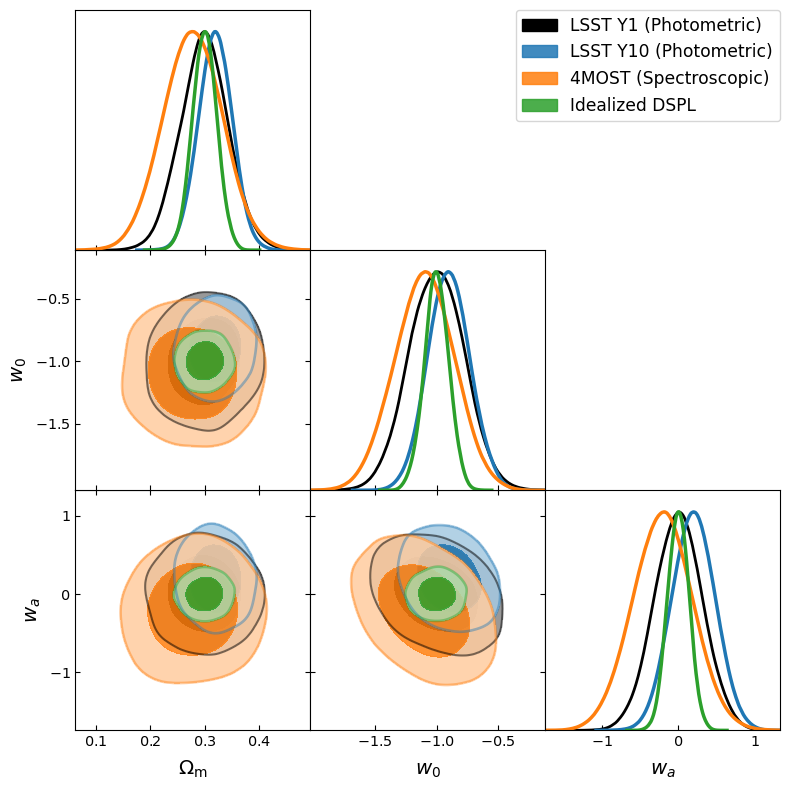

In [8]:
import numpy as np
from getdist import plots, MCSamples
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Generate fake MCMC data for 4 different scenarios
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 5000

# We will simulate 3 parameters: Omega_m, w0, and wa
# Means and covariance matrices to make them look different
s1 = np.random.multivariate_normal([0.30, -1.0, 0.0], [[0.002, 0.001, -0.001], [0.001, 0.05, -0.02], [-0.001, -0.02, 0.1]], n_samples)
s2 = np.random.multivariate_normal([0.32, -0.9, 0.2], [[0.001, 0.0005, -0.0005], [0.0005, 0.03, -0.01], [-0.0005, -0.01, 0.08]], n_samples)
s3 = np.random.multivariate_normal([0.28, -1.1, -0.2], [[0.003, -0.001, 0.001], [-0.001, 0.06, -0.03], [0.001, -0.03, 0.15]], n_samples)
s4 = np.random.multivariate_normal([0.30, -1.0, 0.0], [[0.0005, 0.0, 0.0], [0.0, 0.01, 0.0], [0.0, 0.0, 0.02]], n_samples)

# Define parameter names (internal use) and LaTeX labels (for plotting)
names = ['om', 'w0', 'wa']
labels = [r'\Omega_{\rm m}', r'w_0', r'w_a']

# ---------------------------------------------------------
# 2. Convert raw numpy arrays to getdist MCSamples objects
# ---------------------------------------------------------
# The 'label' argument here automatically generates the legend later!
sample1 = MCSamples(samples=s1, names=names, labels=labels, label='LSST Y1 (Photometric)')
sample2 = MCSamples(samples=s2, names=names, labels=labels, label='LSST Y10 (Photometric)')
sample3 = MCSamples(samples=s3, names=names, labels=labels, label='4MOST (Spectroscopic)')
sample4 = MCSamples(samples=s4, names=names, labels=labels, label='Idealized DSPL')

# ---------------------------------------------------------
# 3. Plotting with getdist
# ---------------------------------------------------------
# Initialize the plotter (width_inch controls the overall size)
g = plots.get_subplot_plotter(width_inch=8)

# Configure global settings (like font sizes)
g.settings.axes_fontsize = 12
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14

# Generate the triangle (corner) plot
g.triangle_plot(
    [sample1, sample2, sample3, sample4], 
    filled=True,  # Set to False to prevent muddy overlaps with 4 contours
    contour_colors=['black', '#1f77b4', '#ff7f0e', '#2ca02c'], # Custom colors
    # contour_ls=['-', '--', '-.', ':'], # Line styles: solid, dashed, dash-dot, dotted
    contour_lws=[2, 2.5, 2.5, 2.5]     # Line widths
)

# Optional: Add a title or tweak the layout
# plt.suptitle("getdist 4-Scenario Test", fontsize=18, y=1.02)

# Save or display
# g.export('getdist_4_contours.pdf')
plt.show()